<a href="https://www.kaggle.com/code/gpreda/unemployment-rate-in-eu-countries-grouped-by-sex?scriptVersionId=259191261" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<br>
<center><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b7/Flag_of_Europe.svg/1280px-Flag_of_Europe.svg.png" width=400></img></center>
<br><br><br><br>

# Introduction


Unemployment rate represents unemployed persons as a percentage of the labour force. The labour force is the total number of people employed and unemployed. Unemployed persons comprise persons aged 15 to 74 who were:   
- **a** - without work during the reference week.   
- **b** -  currently available for work, i.e. were available for paid employment or self-employment before the end of the two weeks following the reference week.   
- **c** -  actively seeking work, i.e. had taken specific steps in the four weeks period ending with the reference week to seek paid employment or self-employment or who found a job to start later, i.e. within a period of, at most, three months.   

The indicator is based on the EU Labour Force Survey.


We will represent the evolution in time for each country, separate for each sex.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/unemployment-rate-by-sex/estat_tesem120_en.csv")

# Glimpse the data

In [3]:
df.shape

(1728, 11)

In [4]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,DATAFLOW,LAST UPDATE,freq,age,unit,sex,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2009,5.3,NaN,NaN
1,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2010,4.9,NaN,NaN
2,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2011,4.8,NaN,NaN
3,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2012,5.0,NaN,NaN
4,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2013,5.5,NaN,NaN


# Cleaning and configs

In [5]:
df = df.replace([np.inf, -np.inf], np.nan)

In [6]:
import warnings
warnings.filterwarnings("ignore")

# Data exploration

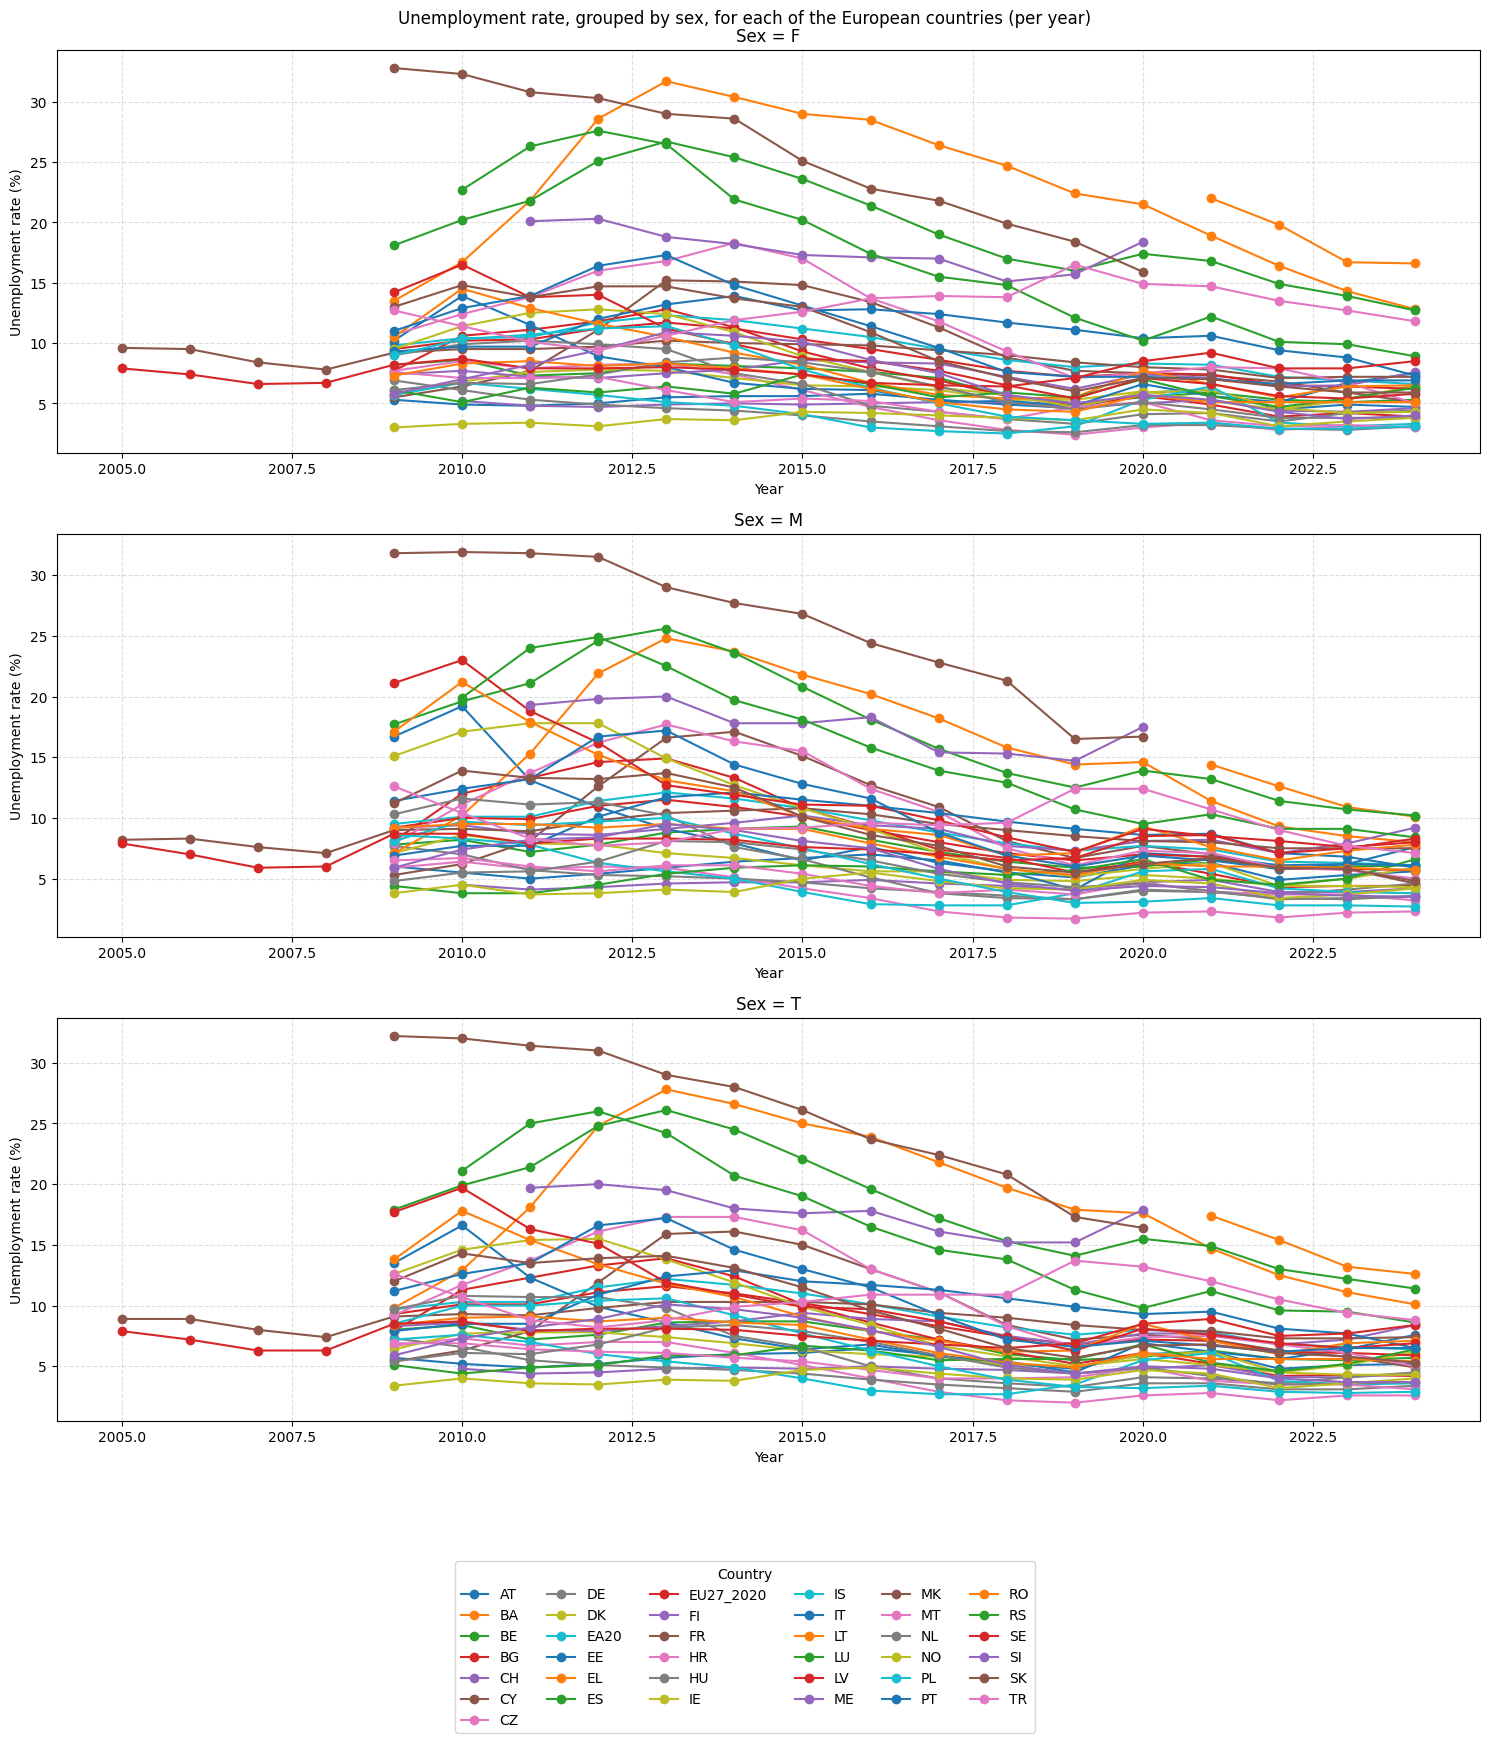

In [7]:
df = df[(df["age"] == "Y15-74") & (df["unit"] == "PC_ACT")]


sexes = ["F","M","T"]
fig, axes = plt.subplots(3, 1, figsize=(15,15), sharey=False)

for i, sex in enumerate(sexes):
    ax = axes[i]
    sub = df[df["sex"] == sex]
    for geo, grp in sub.groupby("geo"):
        ax.plot(grp["TIME_PERIOD"], grp["OBS_VALUE"], marker="o", label=geo)
    ax.set_title(f"Sex = {sex}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Unemployment rate (%)")
    ax.grid(True, linestyle="--", alpha=0.4)

# One legend for all countries, below plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5,-0.05), ncol=6, title="Country")
plt.suptitle("Unemployment rate, grouped by sex, for each of the European countries (per year)")
plt.tight_layout()
plt.show()
